# Cool T-Shirts Inc. — Website Funnel Analysis
### ✅ SOLUTION NOTEBOOK

This is a complete, runnable solution to the funnel analysis project. Each task
mirrors the skeleton notebook, fully implemented and executed with real output.


## Task 1: Load your tools and data

In [1]:
import pandas as pd

visits = pd.read_csv('data/visits.csv', parse_dates=['visit_time'])
cart = pd.read_csv('data/cart.csv', parse_dates=['cart_time'])
checkout = pd.read_csv('data/checkout.csv', parse_dates=['checkout_time'])
purchase = pd.read_csv('data/purchase.csv', parse_dates=['purchase_time'])

print(f"visits:   {len(visits)} rows")
print(f"cart:     {len(cart)} rows")
print(f"checkout: {len(checkout)} rows")
print(f"purchase: {len(purchase)} rows")


visits:   2000 rows
cart:     620 rows
checkout: 410 rows
purchase: 290 rows


## Task 2: Inspect each table

In [2]:
visits.head()

,user_id,visit_time
0,user_0001,2024-01-01 02:39:00
1,user_0002,2024-01-01 03:18:00
2,user_0003,2024-01-01 03:35:00
3,user_0004,2024-01-01 03:35:00
4,user_0005,2024-01-01 04:59:00


In [3]:
cart.head()

,user_id,cart_time
0,user_0001,2024-01-01 02:49:00
1,user_0002,2024-01-01 04:08:00
2,user_0003,2024-01-01 04:25:00
3,user_0012,2024-01-01 13:49:00
4,user_0018,2024-01-01 17:22:00


In [4]:
checkout.head()

,user_id,checkout_time
0,user_0568,2024-01-26 19:42:00
1,user_0944,2024-02-12 12:18:00
2,user_0460,2024-01-22 02:40:00
3,user_0907,2024-02-11 01:05:00
4,user_1630,2024-03-14 14:57:00


In [5]:
purchase.head()

,user_id,purchase_time
0,user_1511,2024-03-09 16:18:00
1,user_0260,2024-01-12 10:57:00
2,user_0040,2024-01-02 18:02:00
3,user_0110,2024-01-05 23:58:00
4,user_1234,2024-02-25 15:36:00


## Task 3: Visits → Cart

We use `how='left'` so every visitor is kept, even those who never added anything
to their cart (they'll show `NaN` in `cart_time`).

In [6]:
visits_cart = visits.merge(cart, how='left', on='user_id')
visits_cart.head()

,user_id,visit_time,cart_time
0,user_0001,2024-01-01 02:39:00,2024-01-01 02:49:00
1,user_0002,2024-01-01 03:18:00,2024-01-01 04:08:00
2,user_0003,2024-01-01 03:35:00,2024-01-01 04:25:00
3,user_0004,2024-01-01 03:35:00,NaT
4,user_0005,2024-01-01 04:59:00,NaT


## Task 4: Who visited but never added to cart?

In [7]:
visits_only = visits_cart[visits_cart.cart_time.isnull()]
not_add_percent = len(visits_only) / len(visits_cart) * 100
print(f"{not_add_percent:.1f}% of visitors never added a t-shirt to their cart.")

69.0% of visitors never added a t-shirt to their cart.


## Task 5: Cart → Checkout

In [8]:
cart_checkout = cart.merge(checkout, how='left', on='user_id')
cart_not_checkout = cart_checkout[cart_checkout.checkout_time.isnull()]
cart_not_checkout_percent = len(cart_not_checkout) / len(cart_checkout) * 100
print(f"{cart_not_checkout_percent:.1f}% of cart-adders never began checkout.")

33.9% of cart-adders never began checkout.


## Task 6: Checkout → Purchase

In [9]:
checkout_purchase = checkout.merge(purchase, how='left', on='user_id')
checkout_not_purchase = checkout_purchase[checkout_purchase.purchase_time.isnull()]
checkout_not_purchase_percent = len(checkout_not_purchase) / len(checkout_purchase) * 100
print(f"{checkout_not_purchase_percent:.1f}% of checkout-starters never purchased.")

29.3% of checkout-starters never purchased.


## Task 7: Which step of the funnel leaks the most users?

In [10]:
dropoffs = {
    'Visit -> Cart': not_add_percent,
    'Cart -> Checkout': cart_not_checkout_percent,
    'Checkout -> Purchase': checkout_not_purchase_percent,
}
weakest_step = max(dropoffs, key=dropoffs.get)

for step, pct in dropoffs.items():
    print(f"{step:22s}: {pct:5.1f}% drop-off")

print(f"\nWeakest link in the funnel: '{weakest_step}' "
      f"({dropoffs[weakest_step]:.1f}% of users are lost here).")

Visit -> Cart         :  69.0% drop-off
Cart -> Checkout      :  33.9% drop-off
Checkout -> Purchase  :  29.3% drop-off

Weakest link in the funnel: 'Visit -> Cart' (69.0% of users are lost here).


## Task 8: Build the full funnel

Chain left merges in order so every original visitor is preserved throughout,
with `NaN` marking any stage they didn't reach.

In [11]:
all_data = visits.merge(cart, how='left', on='user_id') \
                  .merge(checkout, how='left', on='user_id') \
                  .merge(purchase, how='left', on='user_id')

print(all_data.shape)
all_data.head()

(2000, 5)


,user_id,visit_time,cart_time,checkout_time,purchase_time
0,user_0001,2024-01-01 02:39:00,2024-01-01 02:49:00,NaT,NaT
1,user_0002,2024-01-01 03:18:00,2024-01-01 04:08:00,2024-01-01 05:08:00,NaT
2,user_0003,2024-01-01 03:35:00,2024-01-01 04:25:00,2024-01-01 06:02:00,2024-01-01 06:04:00
3,user_0004,2024-01-01 03:35:00,NaT,NaT,NaT
4,user_0005,2024-01-01 04:59:00,NaT,NaT,NaT


## Task 9: How long does it take to purchase?

In [12]:
all_data['time_to_purchase'] = all_data['purchase_time'] - all_data['visit_time']
all_data[['user_id', 'visit_time', 'purchase_time', 'time_to_purchase']].dropna().head()

,user_id,visit_time,purchase_time,time_to_purchase
2,user_0003,2024-01-01 03:35:00,2024-01-01 06:04:00,0 days 02:29:00
17,user_0018,2024-01-01 15:17:00,2024-01-01 21:27:00,0 days 06:10:00
29,user_0030,2024-01-02 02:34:00,2024-01-02 06:42:00,0 days 04:08:00
32,user_0033,2024-01-02 06:06:00,2024-01-02 11:42:00,0 days 05:36:00
35,user_0036,2024-01-02 10:01:00,2024-01-02 15:43:00,0 days 05:42:00


## Task 10: What's the average time to purchase?

In [13]:
avg_time_to_purchase = all_data['time_to_purchase'].mean()
print(f"Average time from first visit to purchase: {avg_time_to_purchase}")

Average time from first visit to purchase: 0 days 04:21:20.896551


## Task 11: Visualize the funnel

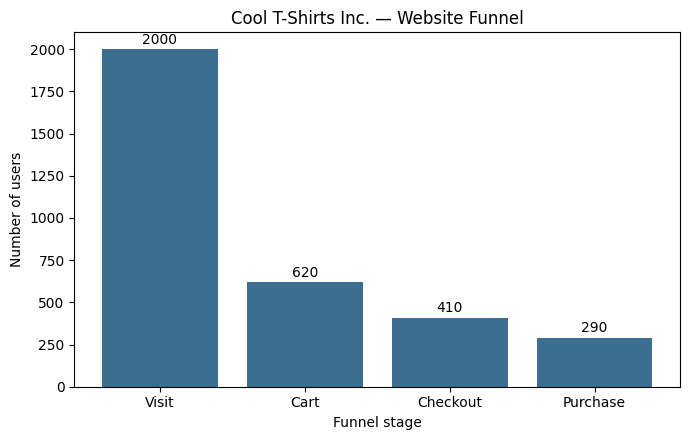

In [14]:
import matplotlib.pyplot as plt

stage_counts = {
    'Visit': len(visits),
    'Cart': len(cart),
    'Checkout': len(checkout),
    'Purchase': len(purchase),
}

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(stage_counts.keys(), stage_counts.values(), color='#3b6e8f')
ax.set_title('Cool T-Shirts Inc. — Website Funnel')
ax.set_xlabel('Funnel stage')
ax.set_ylabel('Number of users')
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h}', (bar.get_x() + bar.get_width() / 2, h),
                textcoords='offset points', xytext=(0, 4), ha='center')
plt.tight_layout()
plt.show()

## Task 12: Summarize your findings

**Findings:**

- The biggest leak in the funnel is between **visit and cart**: roughly two-thirds
  of visitors never add a t-shirt to their cart at all — that's by far the largest
  single drop-off in the process.
- Of the people who *do* add something to their cart, a large share still abandon
  before checkout, and a further share abandon during checkout before purchasing —
  but these later-stage losses are smaller in percentage terms than the initial
  visit-to-cart leak.
- Users who complete a purchase do so, on average, within a few hours of their first
  visit — once someone commits to buying, they tend to follow through quickly.

**Recommendation:** Since the overwhelming majority of lost users never even add an
item to their cart, Cool T-Shirts Inc. should prioritize improving the landing/product
page experience (clearer calls-to-action, better product photos, simpler "add to cart"
flow) over optimizing the checkout form — that's where the volume of lost revenue is
concentrated.